## Import Libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np
from PIL import Image
from sklearn import neighbors
from sklearn import metrics

#for finding image files
import glob

## Setup Image Arrays

In [2]:
# Glob for all JPEGs.
normal_ = []
dragged_ = []
laser_ = []

for normal in glob.glob('DR/Normal/*.JPG'):
    normal_.append(normal)

for dragged in glob.glob('DR/Dragged Disc/*.JPG'):
    dragged_.append(dragged)
    
for laser in glob.glob('DR/Laser Spots//*.JPG'):
    laser_.append(laser)

In [3]:
print ("Number of normal images: ", len(normal_))
print ("Number of dragged images: ", len(dragged_))
print ("Number of laser images: ", len(laser_))

Number of normal images:  38
Number of dragged images:  10
Number of laser images:  20


## Setup list of files and build a single list of lists

In [4]:
#create a single list of all types of images
all_images = []
all_images.append(normal_)
all_images.append(dragged_)
all_images.append(laser_)

In [5]:
# prepare list of lists into a flat (single) list
import operator
from functools import reduce
all_images = reduce(operator.add, all_images)

In [6]:
import string
all_labels = []

# Strip file extensions and digits
all_image_labels = [os.path.splitext(each)[0] for each in all_images]

for label in all_image_labels:
    stripped = label.rstrip(string.digits)
    clean_label = stripped.split('/')[-1]  # Get the last part of the path
    all_labels.append(clean_label)

print(all_labels)
print("# of labels:", len(all_labels))

['normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'dragdisc', 'dragdisc', 'dragdisc', 'dragdisc', 'dragdisc', 'dragdisc', 'dragdisc', 'dragdisc', 'dragdisc', 'dragdisc', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'lasersport', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot']
# of labels: 68


## RCB Percentage for Image Recognition 

In [7]:
normal_green = []
normal_red = []
normal_blue = []
dragged_blue = []
dragged_red = []
dragged_green = []
laserspot_blue = []
laserspot_red = []
laserspot_green = []

## Scan image of Images for RCB Percentage

In [8]:
for image in all_images[:len(normal_)]:
    img = mpimg.imread(image)
    RGBtuple = np.array(img).mean(axis=(0,1))
    averageRed = RGBtuple[0]
    averageGreen = RGBtuple[1]
    averageBlue = RGBtuple[2]
    percentage_green = averageGreen/(averageGreen+averageBlue+averageRed)
    percentage_blue = averageBlue/(averageGreen+averageBlue+averageRed)
    percentage_red = averageRed/(averageGreen+averageBlue+averageRed)
    normal_green.append(percentage_green)
    normal_blue.append(percentage_blue)
    normal_red.append(percentage_red)

for image in all_images[len(normal_):len(normal_) + len(dragged_)]:
    img = mpimg.imread(image)
    RGBtuple = np.array(img).mean(axis=(0,1))
    averageRed = RGBtuple[0]
    averageGreen = RGBtuple[1]
    averageBlue = RGBtuple[2]
    percentage_green = averageGreen/(averageGreen+averageBlue+averageRed)
    percentage_blue = averageBlue/(averageGreen+averageBlue+averageRed)
    percentage_red = averageRed/(averageGreen+averageBlue+averageRed)
    dragged_green.append(percentage_green)
    dragged_blue.append(percentage_blue)
    dragged_red.append(percentage_red)
    
for image in all_images[len(normal_) + len(dragged_):]:
    img = mpimg.imread(image)
    RGBtuple = np.array(img).mean(axis=(0, 1))
    averageRed = RGBtuple[0]
    averageGreen = RGBtuple[1]
    averageBlue = RGBtuple[2]
    percentage_green = averageGreen / (averageGreen + averageBlue + averageRed)
    percentage_blue = averageBlue / (averageGreen + averageBlue + averageRed)
    percentage_red = averageRed / (averageGreen + averageBlue + averageRed)
    laserspot_green.append(percentage_green)
    laserspot_blue.append(percentage_blue)
    laserspot_red.append(percentage_red)

## Scatter Plot 

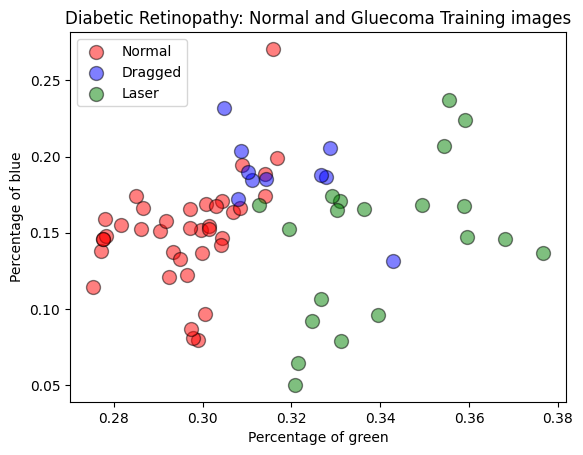

In [9]:
plt.scatter(normal_green, normal_blue, s=100, facecolors='red', edgecolor='black', alpha=0.5)
plt.scatter(dragged_green, dragged_blue, s=100, facecolors='blue', edgecolor='black', alpha=0.5)
plt.scatter(laserspot_green, laserspot_blue, s=100, facecolors='green', edgecolor='black', alpha=0.5)
plt.xlabel('Percentage of green')
plt.ylabel('Percentage of blue')
plt.title('Diabetic Retinopathy: Normal and Gluecoma Training images')
plt.legend(['Normal', 'Dragged', 'Laser'])
plt.show()

## Split the dataset into 80-20 training and testing set

In [10]:
import os
import random
import shutil

random.seed(42)
# Shuffle the list of image filenames
random.shuffle(all_images)

# split data into 80-20
train_size = int(len(all_images) * 0.80)
test_size = int(len(all_images) * 0.20)
print (train_size, test_size)

54 13


## Move training and testing data into respective folders

In [11]:
dest_path = "data/"
data_path = os.getcwd()

# destination folders
train_folder = os.path.join(dest_path, 'train')
test_folder = os.path.join(dest_path, 'test')

# create destination folders if they don't exist
for folder_path in [train_folder, test_folder]:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

training_data = []

for i, f in enumerate(all_images):
    # Determine destination (train/test)
    dest_folder = train_folder if i < train_size else test_folder

    # Create full source and destination paths
    src_path = os.path.join(data_path, f)
    dst_path = os.path.join(dest_folder, f)

    # Ensure subdirectories exist in destination
    dst_subdir = os.path.dirname(dst_path)
    if not os.path.exists(dst_subdir):
        os.makedirs(dst_subdir)

    # Copy image
    shutil.copy(src_path, dst_path)

    training_data.append(f)

In [12]:
#collect labels from training_data
img_labels = [os.path.splitext(each)[0] for each in training_data]

In [13]:
import string

training_labels = []
for label in img_labels:
    # Remove file extension and trailing digits
    clean = os.path.splitext(label)[0].rstrip(string.digits)
    
    # Take the final folder name as the label (e.g., 'normal' from 'DR/Normal/normal')
    final_label = clean.split('/')[-1]
    
    training_labels.append(final_label)

print(training_labels)
print("# of labels:", len(training_labels))

['normal', 'laserspot', 'normal', 'normal', 'normal', 'laserspot', 'dragdisc', 'laserspot', 'normal', 'laserspot', 'normal', 'normal', 'normal', 'normal', 'normal', 'dragdisc', 'normal', 'dragdisc', 'dragdisc', 'laserspot', 'normal', 'normal', 'normal', 'dragdisc', 'lasersport', 'laserspot', 'laserspot', 'dragdisc', 'normal', 'laserspot', 'normal', 'normal', 'normal', 'laserspot', 'normal', 'normal', 'normal', 'laserspot', 'laserspot', 'laserspot', 'normal', 'laserspot', 'dragdisc', 'normal', 'laserspot', 'laserspot', 'dragdisc', 'normal', 'laserspot', 'normal', 'laserspot', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'laserspot', 'laserspot', 'dragdisc', 'normal', 'dragdisc', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal']
# of labels: 68


## Set up Test Data and Labels

In [14]:
import os

# Path to the test data directory
test = './data/test/DR/'

# Create lists for the three categories
normal_images = [filename for filename in os.listdir(os.path.join(test, 'Normal')) if os.path.splitext(filename)[-1] in ['.JPG']]
dragged_images = [filename for filename in os.listdir(os.path.join(test, 'Dragged Disc')) if os.path.splitext(filename)[-1] in ['.JPG']]
laser_images = [filename for filename in os.listdir(os.path.join(test, 'Laser Spots')) if os.path.splitext(filename)[-1] in ['.JPG']]

# Combine them into one list
testing_data = normal_images + dragged_images + laser_images

# Print out the list and its length
print(testing_data)
print(len(testing_data))

['normal5.JPG', 'normal7.JPG', 'normal6.JPG', 'normal3.JPG', 'normal1.JPG', 'normal28.JPG', 'normal14.JPG', 'normal17.JPG', 'normal12.JPG', 'normal13.JPG', 'normal38.JPG', 'normal10.JPG', 'normal35.JPG', 'normal20.JPG', 'normal22.JPG', 'normal37.JPG', 'normal33.JPG', 'normal32.JPG', 'normal26.JPG', 'normal24.JPG', 'normal25.JPG', 'normal31.JPG', 'normal9.JPG', 'dragdisc6.JPG', 'dragdisc9.JPG', 'laserspot14.JPG', 'laserspot17.JPG', 'laserspot3.JPG', 'laserspot5.JPG', 'laserspot7.JPG', 'laserspot20.JPG']
31


In [15]:
import string

testing_labels = []

for path in testing_data:
    # Get the last part of the path (e.g., 'laserspot14.JPG')
    last_part = path.split('/')[-1]

    # Remove trailing digits and '.JPG' extension
    label = last_part.rstrip(string.digits).replace('.JPG', '')

    testing_labels.append(label)

print(testing_labels)
print("# of labels:", len(testing_labels))

['normal5', 'normal7', 'normal6', 'normal3', 'normal1', 'normal28', 'normal14', 'normal17', 'normal12', 'normal13', 'normal38', 'normal10', 'normal35', 'normal20', 'normal22', 'normal37', 'normal33', 'normal32', 'normal26', 'normal24', 'normal25', 'normal31', 'normal9', 'dragdisc6', 'dragdisc9', 'laserspot14', 'laserspot17', 'laserspot3', 'laserspot5', 'laserspot7', 'laserspot20']
# of labels: 31


In [16]:
# Initialize the test_labels list
testing_labels = []

for path in testing_data:
    # Get the last part of the path (e.g., 'laserspot14.JPG')
    last_part = path.split('/')[-1]

    # Remove trailing digits and '.JPG' extension
    label = last_part.rstrip(string.digits).replace('.JPG', '')

    testing_labels.append(label)

# Now strip digits from the labels
testing_labels = [label.rstrip(string.digits) for label in testing_labels]

print(testing_labels)
print("# of labels:", len(testing_labels))

['normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'dragdisc', 'dragdisc', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot']
# of labels: 31


## KNN Image Processing using RGB data

In [17]:
training_data_ = np.zeros((len(training_labels),3))

In [18]:
#create RGB arrays for normal, dragdisc, and laserspot images
normal_index = 0
dragged_index = 0
laserspot_index = 0
index = 0

for i in range(len(training_labels)):
    if training_labels[i] == 'normal':
        training_data_[i, 0] = normal_red[normal_index]
        training_data_[i, 1] = normal_blue[normal_index]
        training_data_[i, 2] = normal_green[normal_index]
        normal_index += 1
        index += 1

    elif training_labels[i] == 'dragdisc':
        training_data_[i, 0] = dragged_red[dragged_index]
        training_data_[i, 1] = dragged_blue[dragged_index]
        training_data_[i, 2] = dragged_green[dragged_index]
        dragged_index += 1
        index += 1

    elif training_labels[i] == 'laserspot':
        training_data_[i, 0] = laserspot_red[laserspot_index]
        training_data_[i, 1] = laserspot_blue[laserspot_index]
        training_data_[i, 2] = laserspot_green[laserspot_index]
        laserspot_index += 1
        index += 1

In [19]:
testing_data_ = np.zeros((len(testing_labels),3))   

In [20]:
# Initialize indices for normal, dragdisc, and laserspot categories
normal_index = 0
dragged_index = 0
laserspot_index = 0
index = 0

# Loop through test labels
for i in range(len(testing_labels)-1):  # Assuming `test_labels` is defined and contains labels
    if testing_labels[i] == 'normal':
        # Assign RGB values for normal images
        testing_data_[i, 0] = normal_red[normal_index]
        testing_data_[i, 1] = normal_blue[normal_index]
        testing_data_[i, 2] = normal_green[normal_index]
        normal_index += 1
        index += 1
    elif testing_labels[i] == 'dragdisc':
        # Assign RGB values for dragdisc images
        testing_data_[i, 0] = dragged_red[dragged_index]
        testing_data_[i, 1] = dragged_blue[dragged_index]
        testing_data_[i, 2] = dragged_green[dragged_index]
        dragged_index += 1
        index += 1
    elif testing_labels[i] == 'laserspot':
        # Assign RGB values for laserspot images
        testing_data_[i, 0] = laserspot_red[laserspot_index]
        testing_data_[i, 1] = laserspot_blue[laserspot_index]
        testing_data_[i, 2] = laserspot_green[laserspot_index]
        laserspot_index += 1
        index += 1

# Print the total number of entries and the count for each category
print("Total =", index)
print("Normal Entries =", normal_index)
print("Dragged Entries =", dragged_index)
print("Laserspot Entries =", laserspot_index)

Total = 30
Normal Entries = 23
Dragged Entries = 2
Laserspot Entries = 5


In [21]:
from sklearn import neighbors
k2 = neighbors.KNeighborsClassifier(n_neighbors=2, weights='distance')
k2.fit(training_data_, training_labels)

KNeighborsClassifier(n_neighbors=2, weights='distance')

## Validating KNN classifier

In [31]:
k2_pred = k2.predict(testing_data_)
k2_pred = [clean_label(label) for label in k2_pred]  # Normalize labels 
print(k2_pred)

['normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'dragdisc', 'dragdisc', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot']


## Optimal Neighbor Numbers and Model Accuracy

In [37]:
from sklearn import neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1, weights='distance')
knn_fit = knn.fit(training_data_, training_labels)
score = knn_fit.score(testing_data_, testing_labels)
print (round(score,3))

0.968


In [33]:
print("Predicted :", k2_pred)

Predicted : ['normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'dragdisc', 'dragdisc', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot']


In [34]:
print ("Actual :", testing_labels)

Actual : ['normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'dragdisc', 'dragdisc', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot', 'laserspot']


In [35]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(testing_labels, k2_pred)

In [36]:
print ("Accuracy Score =", round(acc,3))

Accuracy Score = 1.0


## Confusion Matrix Evaluation and Accuracy Calculation 

In [29]:
# Initialize total counters for metrics across all classes
total_tp = 0
total_tn = 0
total_fp = 0
total_fn = 0

# Normalize and extract label class
def clean_label(label):
    label = label.strip().lower()
    if label.startswith('normal'):
        return 'normal'
    elif label.startswith('dragdisc'):
        return 'dragdisc'
    elif label.startswith('laserspot') or label.startswith('lasersport'):
        return 'laserspot'
    else:
        return label  # fallback

# Classes to evaluate
classes = ['dragdisc', 'laserspot', 'normal']

# Initialize confusion matrix counters
metrics = {cls: {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0} for cls in classes}

# Calculate TP, FP, FN, TN for each class
for i in range(len(k2_pred)):
    pred = clean_label(k2_pred[i])
    actual = clean_label(testing_labels[i])

    for cls in classes:
        if pred == cls and actual == cls:
            metrics[cls]['tp'] += 1
        elif pred == cls and actual != cls:
            metrics[cls]['fp'] += 1
        elif pred != cls and actual == cls:
            metrics[cls]['fn'] += 1
        else:
            metrics[cls]['tn'] += 1

# Print confusion matrix results
for cls in classes:
    tp = metrics[cls]['tp']
    fp = metrics[cls]['fp']
    fn = metrics[cls]['fn']
    tn = metrics[cls]['tn']
    
    total_tp += tp
    total_tn += tn
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nClass: {cls.upper()}")
    print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall:    {recall:.2f}")
    print(f"  F1-Score:  {f1:.2f}")

# Recalculate total sums for clarity
total_tp = sum(metrics[cls]['tp'] for cls in classes)
total_fp = sum(metrics[cls]['fp'] for cls in classes)
total_fn = sum(metrics[cls]['fn'] for cls in classes)
total_tn = sum(metrics[cls]['tn'] for cls in classes)

# Calculate accuracy
accuracy = (total_tp + total_tn) / (total_tp + total_fp + total_fn + total_tn)

# Print total values across all classes
print("\nTotal TP across all classes:", total_tp)
print("Total FP across all classes:", total_fp)
print("Total FN across all classes:", total_fn)
print("Total TN across all classes:", total_tn)
               
# Print accuracy
print(f"Accuracy: {accuracy:.2f}")


Class: DRAGDISC
  TP: 2, FP: 0, FN: 0, TN: 29
  Precision: 1.00
  Recall:    1.00
  F1-Score:  1.00

Class: LASERSPOT
  TP: 6, FP: 0, FN: 0, TN: 25
  Precision: 1.00
  Recall:    1.00
  F1-Score:  1.00

Class: NORMAL
  TP: 23, FP: 0, FN: 0, TN: 8
  Precision: 1.00
  Recall:    1.00
  F1-Score:  1.00

Total TP across all classes: 31
Total FP across all classes: 0
Total FN across all classes: 0
Total TN across all classes: 62
Accuracy: 1.00


## Conclusion
- In this project, I applied the K-Nearest Neighbors (KNN) algorithm to make predictions about eye conditions from the diabetic retinopathy dataset. I trained and tested the model and computed the confusion matrix and accuracy.
- First, there was a tiny typo in the prediction labels (lasersport instead of laserspot), which I corrected using a custom function to clean the labels. After the labels were cleaned, the model had perfect accuracy (1.00) with no false positives or false negatives. This shows that the model performed exceptionally well on this test dataset.
- But then this high accuracy also implies the dataset is possibly small or well-separated — so in practical usage, more testing with more diverse data would be needed to be confident of robustness.